In [ ]:
!wget -O maps.tar.gz \
http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/maps.tar.gz
!tar -xzf maps.tar.gz

--2026-09-28 11:30:36--  http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/maps.tar.gz
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.139.28
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.139.28|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 250242400 (239M) [application/x-gzip]
Saving to: ‘maps.tar.gz’

maps.tar.gz         100%[===================>] 238.65M  4.52MB/s    in 53s     

2026-09-28 11:31:29 (4.49 MB/s) - ‘maps.tar.gz’ saved [250242400/250242400]



In [ ]:
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

for split in ["train", "val"]:
    source_dir = Path("maps") / split
    satellite_dir = Path("maps_preprocessed") / split / "satellite"
    map_dir = Path("maps_preprocessed") / split / "map"

    satellite_dir.mkdir(parents=True, exist_ok=True)
    map_dir.mkdir(parents=True, exist_ok=True)

    image_paths = sorted(source_dir.glob("*.jpg"))

    for image_path in tqdm(image_paths, desc=f"Подготовка {split}"):
        image = Image.open(image_path).convert("RGB")
        width, height = image.size

        satellite = image.crop((0, 0, width // 2, height))
        target_map = image.crop((width // 2, 0, width, height))

        satellite = satellite.resize(
            (256, 256),
            Image.Resampling.BILINEAR
        )

        target_map = target_map.resize(
            (256, 256),
            Image.Resampling.BILINEAR
        )

        filename = image_path.stem + ".png"

        satellite.save(satellite_dir / filename)
        target_map.save(map_dir / filename)

Подготовка train:   0%|          | 0/1096 [00:00<?, ?it/s]

Подготовка val:   0%|          | 0/1098 [00:00<?, ?it/s]

In [ ]:
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torchvision.transforms.functional as TF

from torch.utils.data import Dataset, DataLoader

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Устройство:", device)

Устройство: cuda


In [ ]:
TRAIN_DIR = Path("maps_preprocessed/train")
VAL_DIR = Path("maps_preprocessed/val")

class SatelliteMapDataset(Dataset):
    def __init__(self, root_dir, image_size=256, load_size=286, augment=False):
        self.root_dir = Path(root_dir)
        self.image_size = image_size
        self.load_size = load_size
        self.augment = augment

        self.satellite_paths = sorted(
            (self.root_dir / "satellite").glob("*.png")
        )

        self.map_paths = sorted(
            (self.root_dir / "map").glob("*.png")
        )

    def __len__(self):
        return len(self.satellite_paths)

    def __getitem__(self, index):
        satellite = Image.open(
            self.satellite_paths[index]
        ).convert("RGB")

        target_map = Image.open(
            self.map_paths[index]
        ).convert("RGB")

        if self.augment:
            satellite = TF.resize(
                satellite,
                [self.load_size, self.load_size],
                antialias=True
            )

            target_map = TF.resize(
                target_map,
                [self.load_size, self.load_size],
                antialias=True
            )

            top = random.randint(0, self.load_size - self.image_size)
            left = random.randint(0, self.load_size - self.image_size)

            satellite = TF.crop(
                satellite,
                top,
                left,
                self.image_size,
                self.image_size
            )

            target_map = TF.crop(
                target_map,
                top,
                left,
                self.image_size,
                self.image_size
            )

            if random.random() > 0.5:
                satellite = TF.hflip(satellite)
                target_map = TF.hflip(target_map)

        else:
            satellite = TF.resize(
                satellite,
                [self.image_size, self.image_size],
                antialias=True
            )

            target_map = TF.resize(
                target_map,
                [self.image_size, self.image_size],
                antialias=True
            )

        satellite = TF.to_tensor(satellite) * 2.0 - 1.0
        target_map = TF.to_tensor(target_map) * 2.0 - 1.0

        return satellite, target_map


IMAGE_SIZE = 256
BATCH_SIZE = 4

train_dataset = SatelliteMapDataset(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    load_size=286,
    augment=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

print("Train:", len(train_dataset))


Train: 1096


In [ ]:
class DownBlock(nn.Module):
    def __init__(self, in_channels, out_channels, normalize=True):
        super().__init__()

        layers = [
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=not normalize
            )
        ]

        if normalize:
            layers.append(nn.BatchNorm2d(out_channels))

        layers.append(nn.LeakyReLU(0.2, inplace=True))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=False):
        super().__init__()

        layers = [
            nn.ConvTranspose2d(
                in_channels,
                out_channels,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False
            ),
            nn.BatchNorm2d(out_channels)
        ]

        if dropout:
            layers.append(nn.Dropout(0.5))

        layers.append(nn.ReLU(inplace=True))

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UNetGenerator(nn.Module):
    def __init__(self, input_channels=3, output_channels=3, features=64):
        super().__init__()

        self.down1 = DownBlock(input_channels, features, normalize=False)
        self.down2 = DownBlock(features, features * 2)
        self.down3 = DownBlock(features * 2, features * 4)
        self.down4 = DownBlock(features * 4, features * 8)
        self.down5 = DownBlock(features * 8, features * 8)
        self.down6 = DownBlock(features * 8, features * 8)
        self.down7 = DownBlock(features * 8, features * 8)
        self.down8 = DownBlock(features * 8, features * 8, normalize=False)

        self.up1 = UpBlock(features * 8, features * 8, dropout=True)
        self.up2 = UpBlock(features * 16, features * 8, dropout=True)
        self.up3 = UpBlock(features * 16, features * 8, dropout=True)
        self.up4 = UpBlock(features * 16, features * 8)
        self.up5 = UpBlock(features * 16, features * 4)
        self.up6 = UpBlock(features * 8, features * 2)
        self.up7 = UpBlock(features * 4, features)

        self.final = nn.Sequential(
            nn.ConvTranspose2d(
                features * 2,
                output_channels,
                kernel_size=4,
                stride=2,
                padding=1
            ),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        d7 = self.down7(d6)
        d8 = self.down8(d7)

        u1 = self.up1(d8)
        u2 = self.up2(torch.cat([u1, d7], dim=1))
        u3 = self.up3(torch.cat([u2, d6], dim=1))
        u4 = self.up4(torch.cat([u3, d5], dim=1))
        u5 = self.up5(torch.cat([u4, d4], dim=1))
        u6 = self.up6(torch.cat([u5, d3], dim=1))
        u7 = self.up7(torch.cat([u6, d2], dim=1))

        return self.final(torch.cat([u7, d1], dim=1))

In [ ]:
class PatchGANDiscriminator(nn.Module):
    def __init__(self, input_channels=3, features=64):
        super().__init__()

        def block(in_channels, out_channels, stride=2, normalize=True):
            layers = [
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=4,
                    stride=stride,
                    padding=1,
                    bias=not normalize
                )
            ]

            if normalize:
                layers.append(nn.BatchNorm2d(out_channels))

            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(input_channels * 2, features, normalize=False),
            *block(features, features * 2),
            *block(features * 2, features * 4),
            *block(features * 4, features * 8, stride=1),
            nn.Conv2d(
                features * 8,
                1,
                kernel_size=4,
                stride=1,
                padding=1
            )
        )

    def forward(self, satellite, target_map):
        return self.model(torch.cat([satellite, target_map], dim=1))

In [ ]:
def initialize_weights(model):
    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(module.weight.data, 0.0, 0.02)

        elif isinstance(module, nn.BatchNorm2d):
            nn.init.normal_(module.weight.data, 1.0, 0.02)
            nn.init.constant_(module.bias.data, 0.0)


generator = UNetGenerator().to(device)
discriminator = PatchGANDiscriminator().to(device)

generator.apply(initialize_weights)
discriminator.apply(initialize_weights)

LEARNING_RATE = 0.0002
LAMBDA_L1 = 100.0

adversarial_loss = nn.BCEWithLogitsLoss()
pixel_loss = nn.L1Loss()

generator_optimizer = torch.optim.Adam(
    generator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

discriminator_optimizer = torch.optim.Adam(
    discriminator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

print("Модели подготовлены.")

Модели подготовлены.


In [ ]:
NUM_EPOCHS = 100

generator_losses = []
discriminator_losses = []

for epoch in range(NUM_EPOCHS):
    generator.train()
    discriminator.train()

    total_generator_loss = 0.0
    total_discriminator_loss = 0.0

    progress_bar = tqdm(
        train_loader,
        desc=f"Эпоха {epoch + 1}/{NUM_EPOCHS}"
    )

    for satellites, target_maps in progress_bar:
        satellites = satellites.to(device, non_blocking=True)
        target_maps = target_maps.to(device, non_blocking=True)

        discriminator_optimizer.zero_grad()

        with torch.no_grad():
            generated_maps = generator(satellites)

        real_prediction = discriminator(satellites, target_maps)
        fake_prediction = discriminator(satellites, generated_maps)

        discriminator_loss_real = adversarial_loss(
            real_prediction,
            torch.ones_like(real_prediction)
        )

        discriminator_loss_fake = adversarial_loss(
            fake_prediction,
            torch.zeros_like(fake_prediction)
        )

        discriminator_loss = (
            discriminator_loss_real + discriminator_loss_fake
        ) / 2.0

        discriminator_loss.backward()
        discriminator_optimizer.step()

        generator_optimizer.zero_grad()

        generated_maps = generator(satellites)

        fake_prediction = discriminator(
            satellites,
            generated_maps
        )

        generator_gan_loss = adversarial_loss(
            fake_prediction,
            torch.ones_like(fake_prediction)
        )

        generator_l1_loss = pixel_loss(
            generated_maps,
            target_maps
        )

        generator_loss = (
            generator_gan_loss
            + LAMBDA_L1 * generator_l1_loss
        )

        generator_loss.backward()
        generator_optimizer.step()

        total_generator_loss += generator_loss.item()
        total_discriminator_loss += discriminator_loss.item()

        progress_bar.set_postfix(
            G=f"{generator_loss.item():.3f}",
            D=f"{discriminator_loss.item():.3f}"
        )

    mean_generator_loss = total_generator_loss / len(train_loader)
    mean_discriminator_loss = total_discriminator_loss / len(train_loader)

    generator_losses.append(mean_generator_loss)
    discriminator_losses.append(mean_discriminator_loss)

    print(
        f"Эпоха {epoch + 1}/{NUM_EPOCHS} | "
        f"Generator loss: {mean_generator_loss:.4f} | "
        f"Discriminator loss: {mean_discriminator_loss:.4f}"
    )

torch.save(
    generator.state_dict(),
    "pix2pix_generator_final.pth"
)

print("\nОбучение завершено.")
print("Генератор сохранён в pix2pix_generator_final.pth")

Эпоха 1/100:   0%|          | 0/274 [00:00<?, ?it/s]

Эпоха 1/100 | Generator loss: 17.2851 | Discriminator loss: 0.4420


Эпоха 2/100:   0%|          | 0/274 [00:00<?, ?it/s]

Эпоха 2/100 | Generator loss: 12.4192 | Discriminator loss: 0.3987


Эпоха 3/100:   0%|          | 0/274 [00:00<?, ?it/s]

...

Эпоха 98/100 | Generator loss: 10.3050 | Discriminator loss: 0.2034


Эпоха 99/100:   0%|          | 0/274 [00:00<?, ?it/s]

Эпоха 99/100 | Generator loss: 10.2574 | Discriminator loss: 0.2061


Эпоха 100/100:   0%|          | 0/274 [00:00<?, ?it/s]

Эпоха 100/100 | Generator loss: 10.3232 | Discriminator loss: 0.1949

Обучение завершено.
Генератор сохранён в pix2pix_generator_final.pth


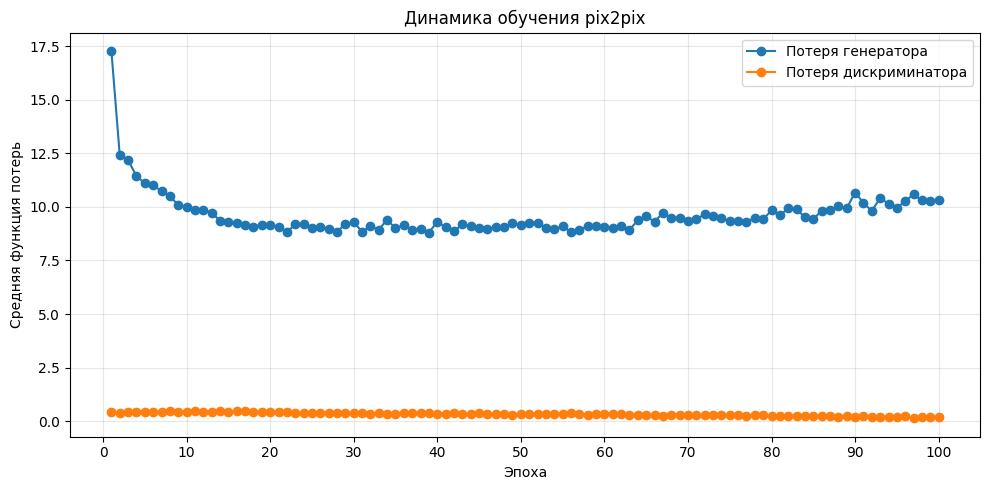

График сохранён: pix2pix_training_losses.png


In [ ]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs,
    generator_losses,
    marker="o",
    label="Потеря генератора"
)

plt.plot(
    epochs,
    discriminator_losses,
    marker="o",
    label="Потеря дискриминатора"
)

plt.xlabel("Эпоха")
plt.ylabel("Средняя функция потерь")
plt.title("Динамика обучения pix2pix")
plt.xticks(range(0, NUM_EPOCHS + 1, 10))
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig("pix2pix_training_losses.png", dpi=150)
plt.show()

print("График сохранён: pix2pix_training_losses.png")

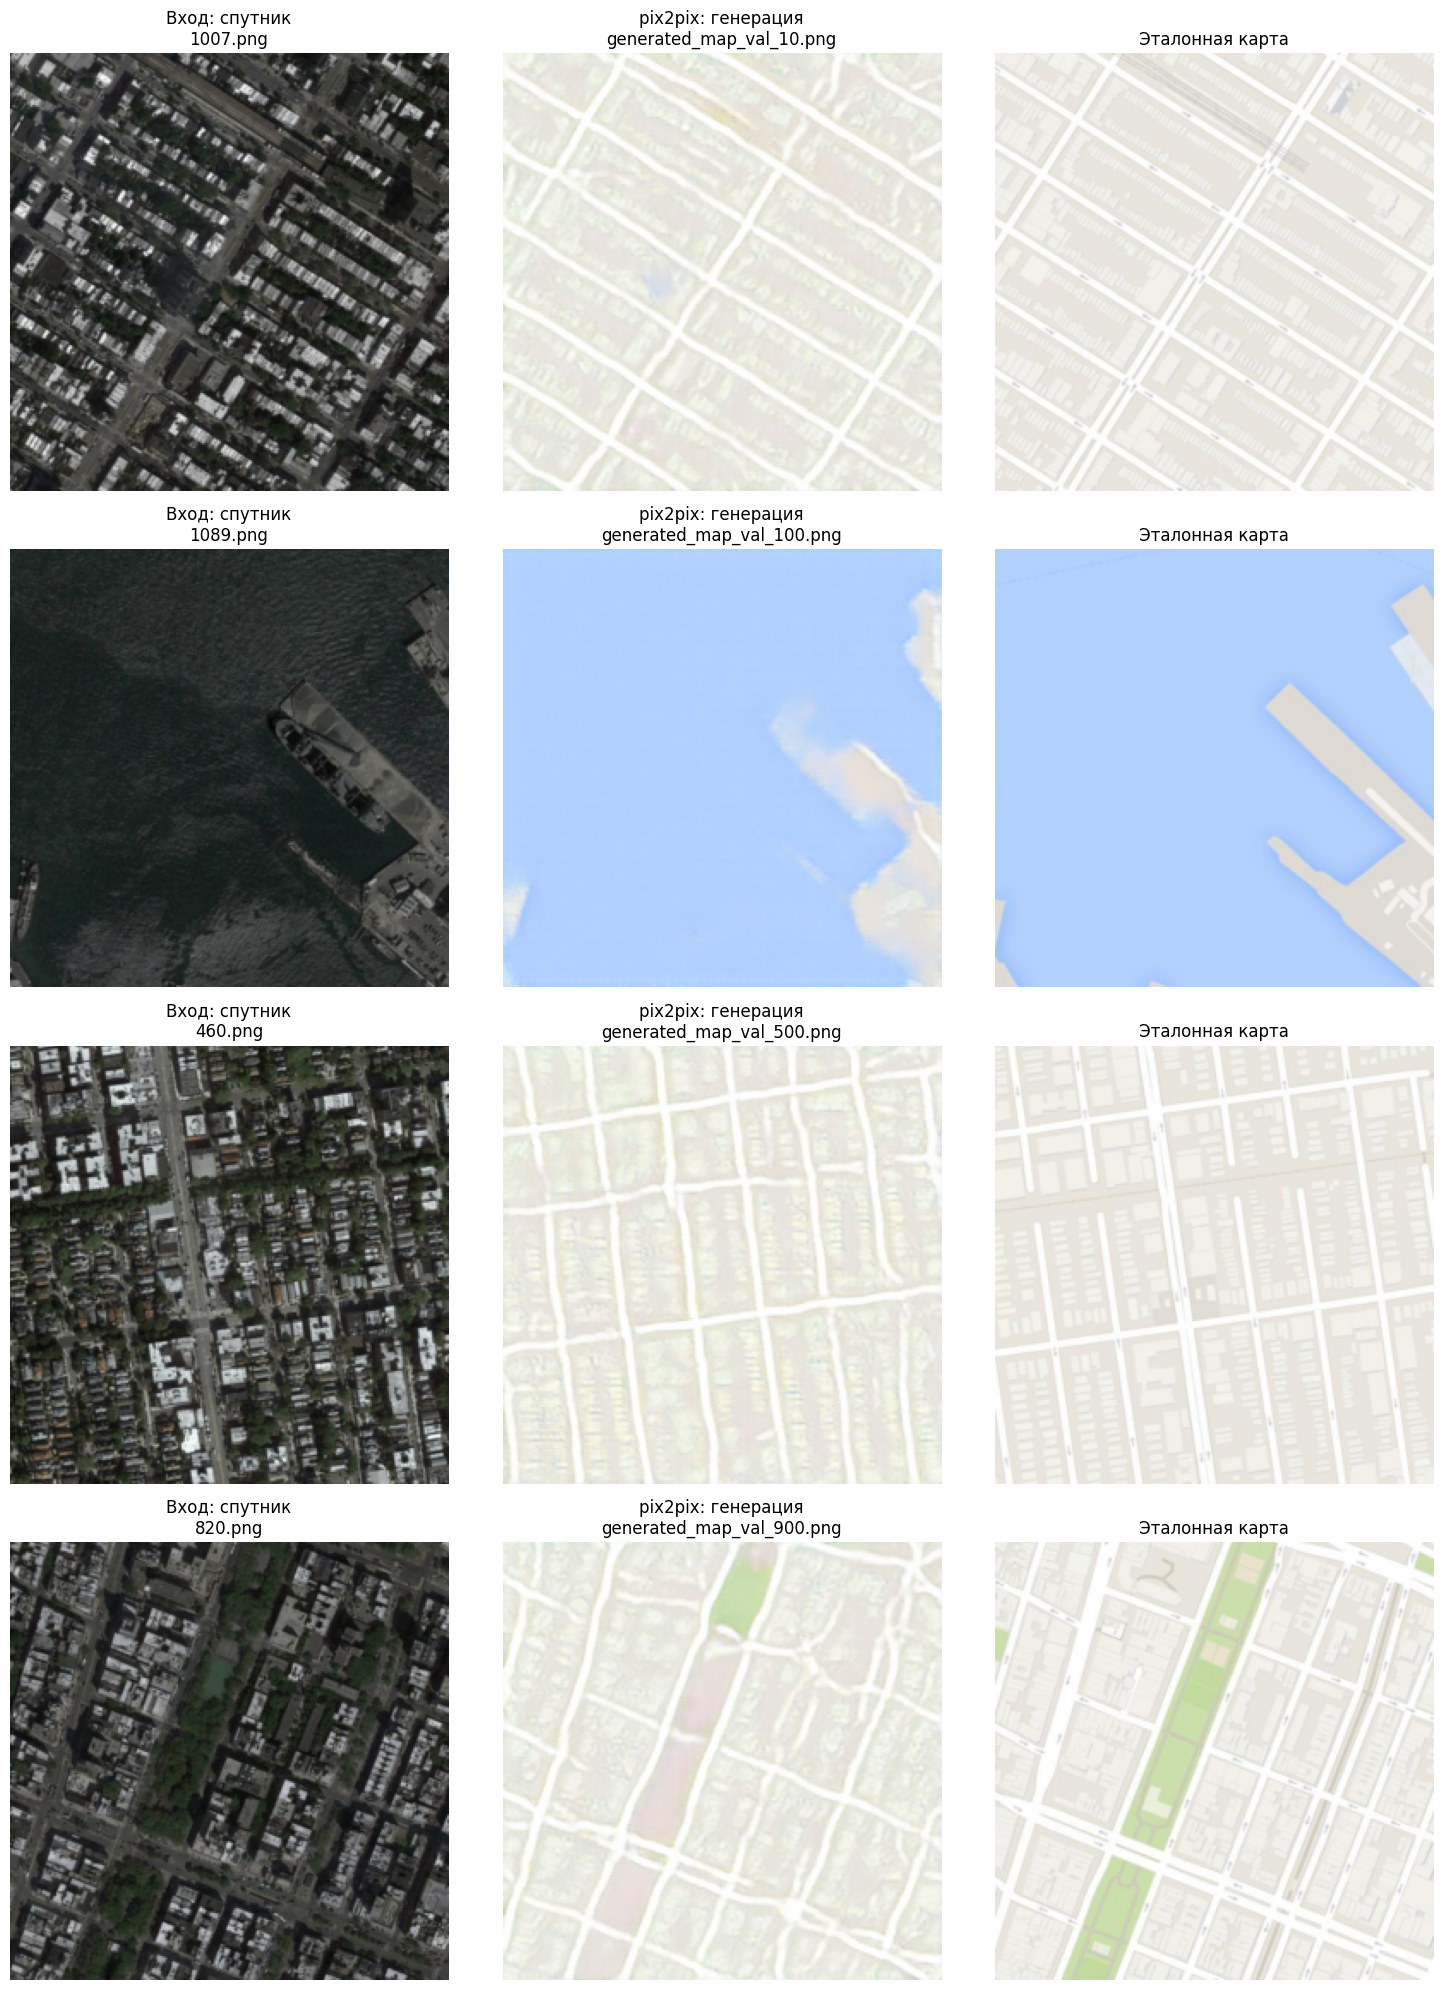

Созданы отдельные карты:
generated_map_val_10.png
generated_map_val_100.png
generated_map_val_500.png
generated_map_val_900.png

Общая таблица сохранена: pix2pix_multiple_examples.png


In [ ]:
SAMPLE_INDICES = [10, 100, 500, 900]

val_satellite_paths = sorted(
    (VAL_DIR / "satellite").glob("*.png")
)

val_map_paths = sorted(
    (VAL_DIR / "map").glob("*.png")
)

generator.eval()

figure, axes = plt.subplots(
    len(SAMPLE_INDICES),
    3,
    figsize=(15, 5 * len(SAMPLE_INDICES))
)

for row, sample_index in enumerate(SAMPLE_INDICES):
    satellite_path = val_satellite_paths[sample_index]
    target_map_path = val_map_paths[sample_index]

    satellite_image = Image.open(satellite_path).convert("RGB")
    target_map_image = Image.open(target_map_path).convert("RGB")

    input_image = TF.resize(
        satellite_image,
        [IMAGE_SIZE, IMAGE_SIZE],
        antialias=True
    )

    input_tensor = TF.to_tensor(input_image)
    input_tensor = input_tensor * 2.0 - 1.0
    input_tensor = input_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        generated_tensor = generator(input_tensor)[0]

    generated_tensor = (generated_tensor + 1.0) / 2.0
    generated_tensor = generated_tensor.clamp(0, 1)

    generated_map_image = TF.to_pil_image(
        generated_tensor.cpu()
    )

    output_file = f"generated_map_val_{sample_index}.png"
    generated_map_image.save(output_file)

    axes[row, 0].imshow(satellite_image)
    axes[row, 0].set_title(
        f"Вход: спутник\n{satellite_path.name}"
    )
    axes[row, 0].axis("off")

    axes[row, 1].imshow(generated_map_image)
    axes[row, 1].set_title(
        f"pix2pix: генерация\n{output_file}"
    )
    axes[row, 1].axis("off")

    axes[row, 2].imshow(target_map_image)
    axes[row, 2].set_title("Эталонная карта")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.savefig(
    "pix2pix_multiple_examples.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

print("Созданы отдельные карты:")
for sample_index in SAMPLE_INDICES:
    print(f"generated_map_val_{sample_index}.png")

print("\nОбщая таблица сохранена: pix2pix_multiple_examples.png")